# Streaming Products from S3 During Commissioning

## Introduction

This notebook demonstrates how to search MAST for commissioning-like data products made during MRT-7b, and then shows how to stream those data products from MAST into memory without the need to make local copies.

<div class="alert alert-warning" style="color:black; background-color:#82caff; border-color:blue;">
    <b>NOTE:</b> This currently relies on an astroquery PR. This is expected to be merged and released in the near future before launch and commissioning.
</div>

This tutorial has been adapted mainly from the MAST notebook [MAST Metadata Search](https://github.com/spacetelescope/mast_notebooks/blob/roman-prelaunch/notebooks/Roman/MAST_metadata_search/MAST_metadata_search.ipynb) and the Nexus tutorial [Working with ADSF](https://github.com/spacetelescope/roman_notebooks/blob/main/notebooks/working_with_asdf/working_with_asdf.ipynb), with additional information added to support streaming from MAST search results.

## Imports

In [11]:
import os
import requests
import roman_datamodels as rdm
from astroquery.mast import MastMissions
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

First, we create our `MastMissions` object to act as our gateway to MAST for searches. If you do not have a MAST AUTH token for accessing MAST (needed for Roman OPS access until after commissioning), or if your token has expired, make one now by visiting [MAST.Auth](https://auth.mast.stsci.edu/info).

Once you have a token, you can set it up as an environment variable for later use, or you can store it in a file called `mast_api_token.txt`. If you use the file method, it must be in the same directory as this notebook or wherever you query MAST for data (both searches and retrievals). The environment variable is typically more convenient.

<div class="alert alert-warning" style="color:black; background-color:#ffc5c5; border-color:red;">
    <b>NOTE:</b> If you have already started running this notebook and want to use the environment variable, you will need to set that BEFORE the imports above, otherwise it will not be captured correctly by your Python environment.
</div>

In [12]:
# Create MastMissions object and assign mission to 'roman'
missions = MastMissions(mission='roman')

# Login to search and retrieve Roman data
token = os.getenv("MAST_API_TOKEN")
if token is None:
    try:
        with open("mast_api_token.txt") as f:
            token = f.read().strip()
    except FileNotFoundError:
        raise ValueError("MAST token not found!")
    
missions.login(token=token)
               
print(f'Mission: {missions.mission}')
print(f'Service: {missions.service}')

INFO: MAST API token accepted, welcome Maxime Rizzo [astroquery.mast.auth]
Mission: roman
Service: search


Next, as an example, here we show how to search for data from MRT-7b with APT program ID (PID) 114, pass 57, and detector WFI04. Be as specific as you can as the more results MAST returns the longer this cell will take to execute.

In [13]:
# Make a list of column names to return in the search results. The results will not be ordered
# in this order, so we will re-order later. The fileSetName, which we need for retrieval,
# is not in this list, but will still be returned.
col_list = ['program', 'execution_plan', 'pass', 'segment', 'visit', 'observation', 
            'optical_element', 'exposure_type', 'instrument_name', 'detector', 'productLevel', 
            'product_type', 'exposure_time', 'exposure_start_time', 'exposure_end_time', 'fileSetName']

# Create a dictionary of search criteria
search = {'program': 114,
         'pass': 57}

# Query with column criteria
results = missions.query_criteria(
    **search,
    select_cols=col_list)

# Re-order the column names 
results = results[col_list]

# Display the first 5 results
print(f'Total number of results: {len(results)}')
results[:5]

Total number of results: 784


program,execution_plan,pass,segment,visit,observation,optical_element,exposure_type,instrument_name,detector,productLevel,product_type,exposure_time,exposure_start_time,exposure_end_time,fileSetName
int64,int64,str2,str1,int64,int64,str4,str9,str3,str5,str7,str13,float64,str27,str27,str42
114,1,57,1,1,1,F062,--,WFI,--,"3, 4",p_visit_coadd,113.8489223114432,2026-10-04T17:22:59.4270000,--,r00114_p_v01057001001001_000p00x40y55_f062
114,1,57,1,1,1,F062,--,WFI,--,"3, 4",p_visit_coadd,113.8489222696937,2026-10-04T17:22:59.4270000,--,r00114_p_v01057001001001_000p00x40y56_f062
114,1,57,1,1,1,F062,--,WFI,--,"3, 4",p_visit_coadd,113.848883694219,2026-10-04T17:22:59.4270000,--,r00114_p_v01057001001001_000p00x41y54_f062
114,1,57,1,1,1,F062,--,WFI,--,"3, 4",p_visit_coadd,113.8489150504024,2026-10-04T17:22:59.4270000,--,r00114_p_v01057001001001_000p00x41y55_f062
114,1,57,1,1,1,F062,--,WFI,--,"3, 4",p_visit_coadd,113.8488601754665,2026-10-04T17:22:59.4270000,--,r00114_p_v01057001001001_000p00x41y56_f062


## Streaming Files from MAST into Memory

Now that we have search results, we can select one and stream it into memory to examine it. You will primarily be interested in the Level 1 (L1) uncalibrated ramps or the Level 2 (L2) calibrated rate images, but there are some additional products as well. See the [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products) article on RDox for more information.

For the retrieval below, the extension for L1 products is `uncal.asdf`, while for L2 products it is `cal.asdf`.

First, we get the list of data products (files) associated with the search results in the table above. We use the `get_unique_product_list()` method to retrieve only the unique data products.

In [14]:
products = missions.get_unique_product_list(results[:5])
products[:5]

product_key,access,dataset,instrument_name,filters,filename,uri,authz_primary_identifier,authz_secondary_identifier,file_suffix,suffix_description,category,size,type,obs_collection,project,mrp,calibration_software_version,crds_context_used,crds_software_version,edp_url
str97,str6,str42,str3,str1,str54,str97,str54,str54,str8,str1,str1,int64,str18,str1,str1,bool,str6,str1,str1,str56
r00114_p_v01057001001001_000p00x40y55_f062_r00114_p_v01057001001001_000p00x40y55_f062_asn.json,PUBLIC,r00114_p_v01057001001001_000p00x40y55_f062,WFI,,r00114_p_v01057001001001_000p00x40y55_f062_asn.json,r00114_p_v01057001001001_000p00x40y55_f062/r00114_p_v01057001001001_000p00x40y55_f062_asn.json,r00114_p_v01057001001001_000p00x40y55_f062_asn.json,r00114_p_v01057001001001_000p00x40y55_f062_asn.json,_asn,,3,1594,asn,,,False,0.22.0,,,/edp/#/roman?start_date=&start_time=&end_date=&end_time=
r00114_p_v01057001001001_000p00x40y55_f062_r00114_p_v01057001001001_000p00x40y55_f062_preview.png,PUBLIC,r00114_p_v01057001001001_000p00x40y55_f062,WFI,,r00114_p_v01057001001001_000p00x40y55_f062_preview.png,r00114_p_v01057001001001_000p00x40y55_f062/r00114_p_v01057001001001_000p00x40y55_f062_preview.png,r00114_p_v01057001001001_000p00x40y55_f062_preview.png,r00114_p_v01057001001001_000p00x40y55_f062_preview.png,_preview,,3,4880,preview,,,False,0.22.0,,,/edp/#/roman?start_date=&start_time=&end_date=&end_time=
r00114_p_v01057001001001_000p00x40y55_f062_r00114_p_v01057001001001_000p00x40y55_f062_thumb.png,PUBLIC,r00114_p_v01057001001001_000p00x40y55_f062,WFI,,r00114_p_v01057001001001_000p00x40y55_f062_thumb.png,r00114_p_v01057001001001_000p00x40y55_f062/r00114_p_v01057001001001_000p00x40y55_f062_thumb.png,r00114_p_v01057001001001_000p00x40y55_f062_thumb.png,r00114_p_v01057001001001_000p00x40y55_f062_thumb.png,_thumb,,3,775,thumbnail,,,False,0.22.0,,,/edp/#/roman?start_date=&start_time=&end_date=&end_time=
r00114_p_v01057001001001_000p00x40y55_f062_r00114_p_v01057001001001_000p00x40y55_f062_coadd.asdf,PUBLIC,r00114_p_v01057001001001_000p00x40y55_f062,WFI,,r00114_p_v01057001001001_000p00x40y55_f062_coadd.asdf,r00114_p_v01057001001001_000p00x40y55_f062/r00114_p_v01057001001001_000p00x40y55_f062_coadd.asdf,r00114_p_v01057001001001_000p00x40y55_f062_coadd.asdf,r00114_p_v01057001001001_000p00x40y55_f062_coadd.asdf,_coadd,,3,2453656,mosaic,,,False,,,,/edp/#/roman?start_date=&start_time=&end_date=&end_time=
r00114_p_v01057001001001_000p00x40y55_f062_r00114_p_v01057001001001_000p00x40y55_f062_segm.asdf,PUBLIC,r00114_p_v01057001001001_000p00x40y55_f062,WFI,,r00114_p_v01057001001001_000p00x40y55_f062_segm.asdf,r00114_p_v01057001001001_000p00x40y55_f062/r00114_p_v01057001001001_000p00x40y55_f062_segm.asdf,r00114_p_v01057001001001_000p00x40y55_f062_segm.asdf,r00114_p_v01057001001001_000p00x40y55_f062_segm.asdf,_segm,,4,396130,level_four_product,,,False,,,,/edp/#/roman?start_date=&start_time=&end_date=&end_time=


In [15]:
filtered = missions.filter_products(products, file_suffix='_cal')
filtered

product_key,access,dataset,instrument_name,filters,filename,uri,authz_primary_identifier,authz_secondary_identifier,file_suffix,suffix_description,category,size,type,obs_collection,project,mrp,calibration_software_version,crds_context_used,crds_software_version,edp_url
str97,str6,str42,str3,str1,str54,str97,str54,str54,str8,str1,str1,int64,str18,str1,str1,bool,str6,str1,str1,str56


In [16]:
tab_index = 3  # Choose which row from the filtered product table you want to retrieve
af = missions.read_product(filtered['filename'][tab_index])

IndexError: index 3 is out of bounds for axis 0 with size 0

Next we can transform the `AsdfFile` object to a datamodel. This is optional and comes down to how you prefer to interface with the data in the ASDF file.

In [ ]:
dm = rdm.open(af)

## Working with ASDF

For more information on working with ASDF files, see the Nexus tutorial [Working with ADSF](https://github.com/spacetelescope/roman_notebooks/blob/main/notebooks/working_with_asdf/working_with_asdf.ipynb). Briefly, you can access the metadata using dot notation as below:

In [ ]:
dm.meta.observation

{'execution_plan': 1, 'exposure': 4, 'observation': 1, 'observation_id': '0011401057001001001031070004', 'pass': 57, 'program': 114, 'segment': 1, 'visit': 1, 'visit_file_activity': '07', 'visit_file_group': 3, 'visit_file_sequence': 1, 'visit_id': '0011401057001001001', 'wfi_parallel': False}

From the `observation` section of the metadata, we can see that this does conform to our search for our MRT-7b example (we see it is program ID 114, pass 57, etc.). If we want to plot the data, which for MRT-7b is a test pattern, then we can also do that.

<div class="alert alert-warning" style="color:black; background-color:#ffc5c5; border-color:red;">
    <b>NOTE:</b> If you run the cell below, or in any other way try to access part of the file and get a long exception that ends with "ClientResponseError: 403, message='Forbidden'" followed by a long URI, then try to re-run the missions.read_product() command above. We believe this may be due to a timeout during the streaming, and are investigating.
</div>

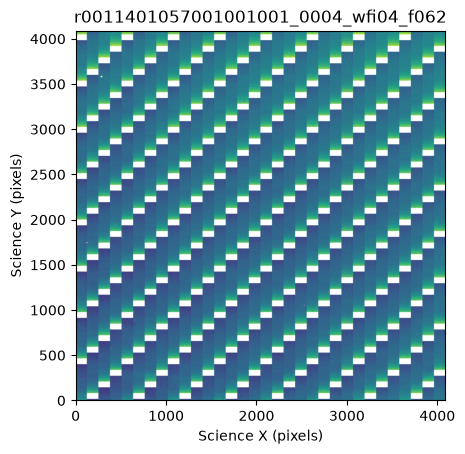

In [ ]:
fig, ax = plt.subplots()
norm = simple_norm(dm.data, percent=99.9)
ax.imshow(dm.data, origin='lower', norm=norm)
ax.set_title(filtered[tab_index]['dataset'])
ax.set_ylabel('Science Y (pixels)')
ax.set_xlabel('Science X (pixels)');